# 1. DATA PREPROCESSING

# Contents in Data Loading & Exploration
1. Importing libraries
2. Loading both datasets
3. Overview of both datasets

# Contents in Data Cleaning
3. Handling Text Inconsistencies
4. Checking for Missing Values
5. Applying Imputer
6. Changing data types (from String to Float : Date Columns)
7. Dropping Columns
8. Categorizing them into Seasons
9. Merge both datasets
10. Apply imputer
11. Checking for Duplicates
12. Applying One-Hot Encoder
13. Data Splitting   



# 1. Importing required Libraries


In [1]:
# Provide data structure : known as DataFrame
# Used for data loading (loading csv files) & Data cleaning(data preprocessing)
# Provide data exploration & analysis (provide the summary of data: mean,standard deviation) & perform aggregiations
# Used for Data Manipulation : filtering, creating, sorting rows
import pandas as pd

# To Store & manipulate arrays
# For computation(arithmatic, linear)  
import numpy as np

# Important for Data Visualization & Statistical plots
import seaborn as sns 

# Important for Data Visualization (generate charts, graphs and others)
import matplotlib.pyplot as plt

# Required for calculating Descriptive Statistics(like mean, median, standard deviation, skewness, kurtosis) for numerical data.
import scipy.stats as stats

# 2. Loading both Datasets

In [2]:
# This line reads data from a CSV file named AttributeDataSet.csv using the pd.read_csv function from the pandas library.
data1 = pd.read_csv('AttributeDataSet.csv')

# It reads data from a CSV file named DressSales.csv and assigns the resulting DataFrame to the variable data2.
data2 = pd.read_csv('DressSales.csv')

# 3.1 Overview of Data1
functions : .head(), .info(), .describe()

In [3]:
# This line displays the first 5 rows of 'data1' 
# Gives the basic idea data's structure, the column names and the data types in each column.
data1.head()

,Dress_ID,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,Material,FabricType,Decoration,PatternType,Recommendation
0,1006032852,Sexy,Low,4.6,M,Summer,o-neck,sleevless,NaN,chiffon,ruffles,animal,1
1,1212192089,Casual,Low,0.0,L,Summer,o-neck,Petal,microfiber,NaN,ruffles,animal,0
2,1190380701,vintage,High,0.0,L,Automn,o-neck,full,polyster,NaN,NaN,print,0
3,966005983,Brief,Average,4.6,L,Spring,o-neck,full,silk,chiffon,embroidary,print,1
4,876339541,cute,Low,4.5,M,Summer,o-neck,butterfly,chiffonfabric,chiffon,bow,dot,0


In [4]:
# Provides concise and informative summary statistics of data1
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Dress_ID        479 non-null    int64  
 1   Style           479 non-null    object 
 2   Price           477 non-null    object 
 3   Rating          479 non-null    float64
 4   Size            479 non-null    object 
 5   Season          477 non-null    object 
 6   NeckLine        476 non-null    object 
 7   SleeveLength    477 non-null    object 
 8   Material        360 non-null    object 
 9   FabricType      223 non-null    object 
 10  Decoration      255 non-null    object 
 11  PatternType     377 non-null    object 
 12  Recommendation  479 non-null    int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 48.8+ KB


# 4. Standardising (Correction) of Spelling in Data1
4.1 Standardizing Season Names
4.2 Standardizing Style Names
4.3 Standardizing Price Names
4.4 Standardizing Size Names
4.5 Standardizing Neckline Names
4.6 Standardizing Material Names
4.7 Standardizing Fabric Type Names
4.8 Standardizing Decoration Names
4.9 Standardizing Pattern Type Names
4.10 Correction of Sleeve Lengths Names

#  4.1 Standardizing Season Names
- There are inconsistencies in how season names are written in the "Season" column obtain from the previous output
- To provide consistency for machine learning & data visualization

In [3]:
 # Extracts all the unique season names that exist in that column &
# stores them in a list or array format.
data1.Season.unique()
# here there is a variety of names and some are duplicated(the same)
# now we correct all of them and standardize them to only 4 names & 
# storing it in an array format

array(['Summer', 'Automn', 'Spring', 'Winter', 'spring', 'winter', nan,
       'Autumn'], dtype=object)

In [4]:
# This lambda function checks each value (x) in the "Season" column to check for spelling error other than 'Spring'
# Otherwise, the original value x is left unchanged
data1.Season = data1.Season.apply(lambda x: "Spring" if x== "spring" else x)

# This lambda function checks each value (x) in the "Season" column to check for spelling error other than 'Autumn'
# Otherwise, the original value x is left unchanged
data1.Season = data1.Season.apply(lambda x: "Autumn" if x== "Automn" else x)

# This lambda function checks each value (x) in the "Season" column to check for spelling error other than 'Winter'
# Otherwise, the original value x is left unchanged
data1.Season = data1.Season.apply(lambda x: "Winter" if x== "winter" else x)

# Printing out all names in the season after correction
data1.Season.unique()

array(['Summer', 'Autumn', 'Spring', 'Winter', nan], dtype=object)

#  4.2 Standardizing Style Names
- There are inconsistencies in how types of style are written in the "Style" column obtain from the previous output
- To provide consistency for machine learning & data visualization

In [6]:
# Extracts all the unique style names that exist in that column &
# stores them in a list or array format & print the result
unique_styles = data1['Style'].unique()
print("Unique categorical strings in the 'Style' column:")
print(unique_styles)

# here there is a variety of names and some are duplicated(the same)
# now we correct all of them and standardize them to only unique(one name with the same definition) names & 
# storing it in an array format

# Replaces variations of "Sexy" and "sexy" with the standardized term "sexy" 
data1.Style= data1.Style.replace(['Sexy'], "sexy")

Unique categorical strings in the 'Style' column:
['sexy' 'Casual' 'vintage' 'Brief' 'cute' 'bohemian' 'Flare' 'party'
 'Novelty' 'work' 'OL' 'fashion']


# 4.3 Standardising Price Names
- There are no typos or duplicated names in Price columns
- This part is solely for the purpose of checking all unique values in Price categorical column. 

In [7]:
# Extracts all the unique style names that exist in that column &
# stores them in a list or array format & print the result
unique_Price = data1['Price'].unique()
print("Unique categorical strings in the 'Price' column:")
print(unique_Price)

# here there is a variety of names and none of them are duplicated(same)
# Price column here is categorical(in string data type) and not numerical, they are only put into different categories.

Unique categorical strings in the 'Price' column:
['Low' 'High' 'Average' 'Medium' 'very-high' nan]


#  4.4 Standardizing Size Names
- There are inconsistencies in how Size variations are written in the "Size" column obtain from the previous output
- To provide consistency for machine learning & data visualization

In [9]:
# Extracts all the unique style names that exist in that column &
# stores them in a list or array format & prnt the result
unique_Size = data1['Size'].unique()
print("Unique categorical strings in the 'Size' column:")
print(unique_Size)

# here there is a variety of names and some are duplicated(the same)
# now we correct all of them and standardize them to only unique(one name with the same definition) names & 
# storing it in an array format

# Replaces "s", "small" with the more descriptive "S" 
data1.Size= data1.Size.replace(['s','small'], "S")

Unique categorical strings in the 'Size' column:
['M' 'L' 'XL' 'free' 'S']


#  4.5 Standardizing NeckLine Names
- There are inconsistencies in how Neck line variations are written in the "NeckLine" column obtain from the previous output
- To provide consistency for machine learning & data visualization
- There are two unique values with similar meaning and names.

In [11]:
# Extracts all the unique style names that exist in that column &
# stores them in a list or array format & print the result
unique_NeckLine = data1['NeckLine'].unique()
print("Unique categorical strings in the 'Neckline' column:")
print(unique_NeckLine)

# here there is a variety of names and some are duplicated(the same)
# now we correct all of them and standardize them to only unique(one name with the same definition) names & 
# storing it in an array format

# Replaces variations of "Sweetheart" with the standardized term ""sweetheart". 
data1.NeckLine= data1.NeckLine.replace(['Sweetheart'], "sweetheart")
# Replaces variations of "sqare-collar" with the standardized term "square-collar". 
data1.NeckLine= data1.NeckLine.replace(['sqare-collar'], "square-collar")

Unique categorical strings in the 'Neckline' column:
['o-neck' 'v-neck' 'boat-neck' 'peterpan-collor' 'ruffled'
 'turndowncollor' 'slash-neck' 'mandarin-collor' 'open' 'sqare-collor'
 'sweetheart' nan 'Scoop' 'halter' 'backless' 'bowneck']


#  4.6 Standardizing Material Names
- There are inconsistencies in how material variations are written in the "Material" column obtain from the previous output
- To provide consistency for machine learning & data visualization
- There are 3 unique values with similar names observed

In [13]:
# Extracts all the unique style names that exist in that column &
# stores them in a list or array format & print the result
unique_Material = data1['Material'].unique()
print("Unique categorical strings in the 'Material' column:")
print(unique_Material)

# here there is a variety of names and some are duplicated(the same)
# now we correct all of them and standardize them to only unique(one name with the same definition) names & 
# storing it in an array format

# Replaces typos and variations of "chiffonfabric" & "shiffon" with the correct term "chiffon" 
data1.Material= data1.Material.replace(['chiffonfabric', 'shiffon'], "chiffon")

# Replaces typos and variations of "sill" & "silk" with the correct term "silk" 
data1.Material= data1.Material.replace(['sill', 'silk'], "silk")

# Replaces typos and variations of "modal" & "model" with the correct term "modal" 
data1.Material= data1.Material.replace(['model', 'modal'], "modal")

Unique categorical strings in the 'Material' column:
[nan 'microfiber' 'polyster' 'silk' 'chiffon' 'cotton' 'nylon' 'other'
 'milksilk' 'linen' 'rayon' 'lycra' 'mix' 'acrylic' 'spandex' 'lace'
 'modal' 'cashmere' 'viscos' 'wool']


#  4.7 Standardizing Fabric Type Names
- There are inconsistencies in how Fabric Type variations are written in the "FabricType" column obtain from the previous output
- To provide consistency for machine learning & data visualization
- There is one unique values with variations of names observed

In [15]:
# Extracts all the unique style names that exist in that column &
# stores them in a list or array format
unique_FabricType = data1['FabricType'].unique()
print("Unique categorical strings in the 'FabricType' column:")
print(unique_FabricType)

# here there is a variety of names and some are duplicated(the same)
# now we correct all of them and standardize them to only unique(one name with the same definition) names & 
# storing it in an array format

# Replaces typos and variations of "flannael" with the standardized term "flannel" 
data1.FabricType= data1.FabricType.replace(['flannael'], "flannel")
# Replaces typos and variations of "sattin" with the standardized term "satin" 
data1.FabricType= data1.FabricType.replace(['sattin'], "satin")
# Replaces typos and variations of "shiffon" with the standardized term "chiffon" 
data1.FabricType= data1.FabricType.replace(['shiffon'], "chiffon")
# Replaces typos and variations of "knitting" with the standardized term "knitted" 
data1.FabricType= data1.FabricType.replace(['knitting'], "knitted")

Unique categorical strings in the 'FabricType' column:
['chiffon' nan 'broadcloth' 'jersey' 'other' 'batik' 'satin' 'flannel'
 'worsted' 'woolen' 'poplin' 'dobby' 'knitted' 'tulle' 'organza' 'lace'
 'Corduroy' 'wollen' 'terry']


#  4.8 Standardizing Decoration Names
- There are inconsistencies in how Decoration variations are written in the "Decoration" column obtain from the previous output
- To provide consistency for machine learning & data visualization
- Although the unique value refers to no value, it must be standardize to one unique value

In [17]:
# Extracts all the unique style names that exist in that column &
# stores them in a list or array format
unique_Decoration = data1['Decoration'].unique()
print("Unique categorical strings in the 'Decoration' column:")
print(unique_Decoration)

# here there is a variety of names and some are duplicated(the same)
# now we correct all of them and standardize them to only unique(one name with the same definition) names & 
# storing it in an array format

# Replaces typos and variations of "none" with the original term "nan"
data1.Deoration= data1.Decoration.replace(['none'], "nan")

Unique categorical strings in the 'Decoration' column:
['ruffles' nan 'embroidary' 'bow' 'beading' 'lace' 'sashes' 'hollowout'
 'pockets' 'sequined' 'applique' 'button' 'Tiered' 'rivet' 'feathers'
 'flowers' 'pearls' 'pleat' 'crystal' 'ruched' 'draped' 'tassel' 'plain'
 'cascading' 'none']


#  4.9 Standardizing Pattern Type Names
- There are inconsistencies in how Pattern Type variations are written in the "PatternType" column obtain from the previous output
- To provide consistency for machine learning & data visualization
- There is one unique value with variation of names. 

In [19]:
# Extracts all the unique style names that exist in that column &
# stores them in a list or array format
unique_PatternType= data1['PatternType'].unique()
print("Unique categorical strings in the 'PatternType' column:")
print(unique_PatternType)

# here there is a variety of names and some are duplicated(the same)
# now we correct all of them and standardize them to only unique(one name with the same definition) names & 
# storing it in an array format

# Replaces typos and variations of "leapord" with the original term "leopard" 
data1.PatternType= data1.PatternType.replace(['leapord'], "leopard")

Unique categorical strings in the 'PatternType' column:
['animal' 'print' 'dot' 'solid' nan 'patchwork' 'striped' 'geometric'
 'plaid' 'leopard' 'floral' 'character' 'splice' 'none']


# 4.9 Correction of Sleeve Lengths Names
- There are inconsistencies in how Sleeve Length variations are written in the "PatternType" column obtain from the previous output
- To provide consistency for machine learning & data visualization
- There are also some unique value with variation of names. 

In [20]:
# This line identifies all the different sleeve length entries &
# stores these unique values in an array format
data1.SleeveLength.unique()

array(['sleevless', 'Petal', 'full', 'butterfly', 'short', 'threequarter',
       'halfsleeve', 'cap-sleeves', 'turndowncollor', 'threequater',
       'capsleeves', 'sleeveless', 'sleeevless', 'half', 'urndowncollor',
       'thressqatar', nan, 'sleveless'], dtype=object)

In [21]:
# Replaces variations of "cap-sleeves" and "capsleeves" with the standardized term "cap sleeves"
data1.SleeveLength= data1.SleeveLength.replace(['cap-sleeves', 'capsleeves'], "cap sleeves")

# Replaces "full" with the more descriptive "full sleeves".
data1.SleeveLength= data1.SleeveLength.replace('full', "full sleeves")

# Replaces variations of "half" and "halfsleeve" with the standardized term "half sleeves".
data1.SleeveLength= data1.SleeveLength.replace(['half','halfsleeve'], "half sleeves")

# Replaces typos and variations of "sleeveless" with the correct term "sleeve less"
data1.SleeveLength= data1.SleeveLength.replace(['sleevless', 'sleeevless', 'sleeveless', 'sleveless'], "sleeve less")

# Replaces typos and variations of "threequarter" with the standardized term "three quarter
data1.SleeveLength= data1.SleeveLength.replace(['threequarter','threequater', 'thressqatar'], "three quater")

# Replaces typos and variations of "turndowncollor" with the original term "turn down collar
data1.SleeveLength= data1.SleeveLength.replace(['turndowncollor','urndowncollor'], "turn down collar")

# Printing out all names of sleeve length after Standardization Process
data1.SleeveLength.unique()


array(['sleeve less', 'Petal', 'full sleeves', 'butterfly', 'short',
       'three quater', 'half sleeves', 'cap sleeves', 'turn down collar',
       nan], dtype=object)

# 5.1  Checking Missing Values for Data1 

In [22]:
# The isnull() function returns a DataFrame showing how many missing values (NaN) there are in each column.
missing_values = data1.isnull().sum()

# Printing a series containing the counts of missing values in data1 DataFrame
print(missing_values)

Dress_ID            0
Style               0
Price               2
Rating              0
Size                0
Season              2
NeckLine            3
SleeveLength        2
Material          119
FabricType        256
Decoration        224
PatternType       102
Recommendation      0
dtype: int64


# 3.2 Overview of Dataset 2 
functions : .head(), .info(), .describe()

In [28]:
# This line displays the first 5 rows of 'data2' 
# Gives the basic idea data's structure, the column names and the data types in each column.
data2.head()

,Dress_ID,29-08-2013,31-08-2013,09-02-2013,09-04-2013,09-06-2013,09-08-2013,09-10-2013,09-12-2013,14-09-2013,...,24-09-2013,26-09-2013,28-09-2013,30-09-2013,10-02-2013,10-04-2013,10-06-2013,10-08-2013,10-10-2013,10-12-2013
0,1.006033e+09,2114,2274,2491,2660,2727,2887,2930,3119,3204,...,3554,3624.0,3706,3746.0,3795.0,3832.0,3897,3923.0,3985.0,4048
1,1.212192e+09,151,275,570,750,813,1066,1164,1558,1756,...,2710,2942.0,3258,3354.0,3475.0,3654.0,3911,4024.0,4125.0,4277
2,1.190381e+09,6,7,7,7,8,8,9,10,10,...,11,11.0,11,11.0,11.0,11.0,11,11.0,11.0,11
3,9.660060e+08,1005,1128,1326,1455,1507,1621,1637,1723,1746,...,1878,1892.0,1914,1924.0,1929.0,1941.0,1952,1955.0,1959.0,1963
4,8.763395e+08,996,1175,1304,1396,1432,1559,1570,1638,1655,...,2032,2156.0,2252,2312.0,2387.0,2459.0,2544,2614.0,2693.0,2736


In [29]:
# Provides concise and informative summary statistics of data2
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dress_ID    479 non-null    float64
 1   29-08-2013  479 non-null    int64  
 2   31-08-2013  479 non-null    int64  
 3   09-02-2013  479 non-null    int64  
 4   09-04-2013  479 non-null    int64  
 5   09-06-2013  479 non-null    int64  
 6   09-08-2013  479 non-null    int64  
 7   09-10-2013  479 non-null    int64  
 8   09-12-2013  479 non-null    object 
 9   14-09-2013  479 non-null    object 
 10  16-09-2013  479 non-null    object 
 11  18-09-2013  479 non-null    object 
 12  20-09-2013  479 non-null    object 
 13  22-09-2013  479 non-null    object 
 14  24-09-2013  479 non-null    int64  
 15  26-09-2013  257 non-null    float64
 16  28-09-2013  479 non-null    int64  
 17  30-09-2013  222 non-null    float64
 18  10-02-2013  220 non-null    float64
 19  10-04-2013  221 non-null    f

# 5. Checking for Missing Values Data2

In [23]:
# The isnull() function returns a DataFrame showing how many missing values (NaN) there are in each column.
missing_values = data2.isnull().sum()

# Printing a series containing the counts of missing values in data2 DataFrame
print(missing_values)

Dress_ID        0
29-08-2013      0
31-08-2013      0
09-02-2013      0
09-04-2013      0
09-06-2013      0
09-08-2013      0
09-10-2013      0
09-12-2013      0
14-09-2013      0
16-09-2013      0
18-09-2013      0
20-09-2013      0
22-09-2013      0
24-09-2013      0
26-09-2013    222
28-09-2013      0
30-09-2013    257
10-02-2013    259
10-04-2013    258
10-06-2013      0
10-08-2013    255
10-10-2013    255
10-12-2013      0
dtype: int64


# 6. Changing Data types 
- (from String to Float : Date Columns)

In [24]:
# Selecting & displaying all object data types in data2 dataset
data2.select_dtypes(include=['object'])

# Below, we can observe that there are 6 date columns with string / object data type

,09-12-2013,14-09-2013,16-09-2013,18-09-2013,20-09-2013,22-09-2013
0,3119,3204,3277,3321,3386,3479
1,1558,1756,1878,1985,2106,2454
2,10,10,10,10,10,11
3,1723,1746,1783,1796,1812,1845
4,1638,1655,1681,1743,1824,1919
...,...,...,...,...,...,...
474,67,68,69,70,72,73
475,525,519,511,501,492,480
476,694,690,686,674,665,658
477,268,270,272,272,264,264


In [25]:
# This line replaces the string value 'Removed' (the null values in string type) with np.NaN from '09-12-2013' date column
data2.loc[data2['09-12-2013']== 'Removed',"09-12-2013"] = np.NaN

# This line replaces the string value 'Removed' (the null values in string type) with np.NaN from '14-09-2013' date column
data2.loc[data2['14-09-2013']== 'removed',"14-09-2013"] = np.NaN

# This line replaces the string value 'Removed' (the null values in string type) with np.NaN from '16-09-2013' date column
data2.loc[data2['16-09-2013']== 'removed',"16-09-2013"] = np.NaN

# This line replaces the string value 'Removed' (the null values in string type) with np.NaN from '18-09-2013' date column
data2.loc[data2['18-09-2013']== 'removed',"18-09-2013"] = np.NaN

# This line replaces the string value 'Removed' (the null values in string type) with np.NaN from '20-09-2013' date column
data2.loc[data2['20-09-2013']== 'removed',"20-09-2013"] = np.NaN

# This line replaces the string value 'Removed' (the null values in string type) with np.NaN from '22-09-2013' date column
data2.loc[data2['22-09-2013']== 'Orders',"22-09-2013"] = np.NaN

# This line creates a list of targeted columns that are intended to be converted to float type.
a= ['09-12-2013','14-09-2013','16-09-2013','18-09-2013','20-09-2013','22-09-2013']

# Converting the object type columns into float type of data type.
data2[a] = data2[a].astype("float")

# 7. Dropping columns in data2
- there are some columns in “Dress Sales” data where there are more than 30% of missing values.

In [26]:
# calculating the total percentage of missing values in each column of the DataFrame data2
data2.isnull().sum()/data2.shape[0]*100

# Column that exceed percentage of missing values are : '26-09-2013' , '30-09-2013' , '10-02-2013' , '10-04-2013' , '10-08-2013' , '10-10-2013'
# all have more than 40% missing values and it is not reliable and will disrupt the whole analysis.  

Dress_ID       0.000000
29-08-2013     0.000000
31-08-2013     0.000000
09-02-2013     0.000000
09-04-2013     0.000000
09-06-2013     0.000000
09-08-2013     0.000000
09-10-2013     0.000000
09-12-2013     0.208768
14-09-2013     0.208768
16-09-2013     0.208768
18-09-2013     0.208768
20-09-2013     0.208768
22-09-2013     0.208768
24-09-2013     0.000000
26-09-2013    46.346555
28-09-2013     0.000000
30-09-2013    53.653445
10-02-2013    54.070981
10-04-2013    53.862213
10-06-2013     0.000000
10-08-2013    53.235908
10-10-2013    53.235908
10-12-2013     0.000000
dtype: float64

In [27]:
# This line calculates the percentage of missing values for each column in data2
PercentageMissingValue = data2.isnull().sum()/data2.shape[0]*100
# This line identifies columns that exceed the 30% missing value threshold
i=PercentageMissingValue[PercentageMissingValue>30].index

# Dropping the columns in "Dress Sales" which have more than 30% of missing values
data2.drop(i,axis=1,inplace=True)

# calculating the number of missing values(after dropping columns) in each remaining column of data2
data2.isnull().sum()

Dress_ID      0
29-08-2013    0
31-08-2013    0
09-02-2013    0
09-04-2013    0
09-06-2013    0
09-08-2013    0
09-10-2013    0
09-12-2013    1
14-09-2013    1
16-09-2013    1
18-09-2013    1
20-09-2013    1
22-09-2013    1
24-09-2013    0
28-09-2013    0
10-06-2013    0
10-12-2013    0
dtype: int64

# 8. Categorising respective dates into Seasons

In [28]:
# This line adds a new column named "Spring" to data2
# Calculating the sales in 'Spring' column by taking values from '09-04-2013'
data2['Spring'] = data2['09-04-2013']

# Defining a list of dates & assigning them that falls under 'summer_columns'
summer_columns = ['29-08-2013', '31-08-2013', '09-06-2013', '09-08-2013', '10-06-2013']
# This line adds a new column named "Summer" to data2
# Calculating the sum of values for sales from each selected rows 
data2['Summer'] = data2[summer_columns].sum(axis=1)

# Defining a list of dates & assigning them that falls under 'winter_columns'
winter_columns = ['09-02-2013', '09-12-2013', '10-12-2013']
# This line adds a new column named "Winter" to data2
# Calculating the sum of values for sales from each selected rows 
data2['Winter'] = data2[winter_columns].sum(axis=1)

# Defining a list of dates & assigning them that falls under 'autumn_columns'
autumn_columns = ['09-10-2013', '14-09-2013', '16-09-2013', '18-09-2013', '20-09-2013', '22-09-2013', '24-09-2013', '28-09-2013']
# This line adds a new column named "Autumn" to data2
# Calculating the sum of values for sales from each selected rows 
data2['Autumn'] = data2[autumn_columns].sum(axis=1)

# calculate the sum of sales in each seasons in inp1 i.e. "Dress Sales".
data2.sum()

Dress_ID      4.321739e+11
29-08-2013    9.488300e+04
31-08-2013    1.004830e+05
09-02-2013    1.070810e+05
09-04-2013    1.436000e+05
09-06-2013    1.459730e+05
09-08-2013    1.516200e+05
09-10-2013    1.533280e+05
09-12-2013    1.596930e+05
14-09-2013    1.627920e+05
16-09-2013    1.653180e+05
18-09-2013    1.678330e+05
20-09-2013    1.723510e+05
22-09-2013    1.764140e+05
24-09-2013    1.786380e+05
28-09-2013    1.866140e+05
10-06-2013    1.989480e+05
10-12-2013    2.079090e+05
Spring        1.436000e+05
Summer        6.919070e+05
Winter        4.746830e+05
Autumn        1.363288e+06
dtype: float64

# 9. Merge both dataset

In [29]:
# Combining both datasets
# data1 as the left table in the join operation.
# data2 as the right table in the join operation.
# -  all rows from the left table (data1) are preserved
data = pd.merge(left=data1,right=data2, how='left', left_on='Dress_ID', right_on='Dress_ID')

#Print out results 
data.head()

,Dress_ID,Style,Price,Rating,Size,Season,NeckLine,SleeveLength,Material,FabricType,...,20-09-2013,22-09-2013,24-09-2013,28-09-2013,10-06-2013,10-12-2013,Spring,Summer,Winter,Autumn
0,1006032852,sexy,Low,4.6,M,Summer,o-neck,sleeve less,NaN,chiffon,...,3386.0,3479.0,3554,3706,3897,4048,2660,13899,9658.0,26857.0
1,1212192089,Casual,Low,0.0,L,Summer,o-neck,Petal,microfiber,NaN,...,2106.0,2454.0,2710,3258,3911,4277,750,6216,6405.0,17311.0
2,1190380701,vintage,High,0.0,L,Autumn,o-neck,full sleeves,polyster,NaN,...,10.0,11.0,11,11,11,11,7,40,28.0,82.0
3,966005983,Brief,Average,4.6,L,Spring,o-neck,full sleeves,silk,chiffon,...,1812.0,1845.0,1878,1914,1952,1963,1455,7213,5012.0,14411.0
4,876339541,cute,Low,4.5,M,Summer,o-neck,butterfly,chiffon,chiffon,...,1824.0,1919.0,2032,2252,2544,2736,1396,7706,5678.0,14676.0


In [30]:
# Printing out the new dataset to check out the columns, data types and values 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Dress_ID        479 non-null    int64  
 1   Style           479 non-null    object 
 2   Price           477 non-null    object 
 3   Rating          479 non-null    float64
 4   Size            479 non-null    object 
 5   Season          477 non-null    object 
 6   NeckLine        476 non-null    object 
 7   SleeveLength    477 non-null    object 
 8   Material        360 non-null    object 
 9   FabricType      223 non-null    object 
 10  Decoration      255 non-null    object 
 11  PatternType     377 non-null    object 
 12  Recommendation  479 non-null    int64  
 13  29-08-2013      479 non-null    int64  
 14  31-08-2013      479 non-null    int64  
 15  09-02-2013      479 non-null    int64  
 16  09-04-2013      479 non-null    int64  
 17  09-06-2013      479 non-null    int

# 10. Applying Hot Deck Imputer for missing values

In [31]:
# Using Impute_Hot_Deck function for the missing values in numerical and also categorical columns
def impute_hot_deck(data, numeric_cols, categorical_cols):
    """
    Impute missing values in a dataset using hot deck imputation.

    Args:
        data: The pandas DataFrame containing the data.
        numeric_cols: A list of column names containing numerical data.
        categorical_cols: A list of column names containing categorical data.

    Returns:
        A new pandas DataFrame with imputed missing values.
    """

    # Impute numeric data using nearest neighbor hot deck (avoiding duplicate selection)
    for col in numeric_cols: # Implementing for loop for numerical columns

        # This lines creates a new dataframe that only have columns with no missing values &
        # arrange them in ascending order
        sorted_data = data.dropna(subset=[col]).sort_values(by=col)  # Sorting by column for nearest neighbor
        # Extracting values from the sorted columns into Numpy Array called as 'donors'"
        # This array will be used as potential values to impute missing values
        donors = sorted_data[col].to_numpy()
        # Ensuring wether each row has a missing value or not, using boolean function
        missing_indices = data[col].isnull()
        # This line replaces missing values in a specific column with donors in that same column. 
        # The random selection allows for a more natural distribution of imputed values, 
        # 'replace=True' ensures that there are no artificial restrictions on which values can be used for imputation.
        data.loc[missing_indices, col] = np.random.choice(donors, size=missing_indices.sum(), replace=True)

    # Impute categorical data using random hot deck (handling potential duplicates)
    for col in categorical_cols: # Implementing for loop for categorical columns

        # Extracting values from the sorted columns into Numpy Array called as 'donors'"
        # This array will be used as potential values to impute missing values
        donors = data[col].dropna().unique()  # Get unique values for categorical imputation
        # Ensuring wether each row has a missing value or not, using boolean function
        missing_indices = data[col].isnull()
        # This line replaces missing values in a specific column with donors in that same column. 
        # The random selection allows for a more natural distribution of imputed values, 
        # 'replace=True' ensures that there are no artificial restrictions on which values can be used for imputation
        data.loc[missing_indices, col] = np.random.choice(donors, size=missing_indices.sum(), replace=True)

    return data.copy()  # Returning copy of the imputed data

# Defining the columns with numerical and categorical data types
numeric_cols = ['Price', 'Rating', '29-08-2013' , '31-08-2013' , '09-02-2013' , '09-04-2013', '09-06-2013' , '09-08-2013' , '09-10-2013' , '09-12-2013' , '14-09-2013' , '16-09-2013' , '18-09-2013' , '20-09-2013' , '22-09-2013' , '24-09-2013' , '28-09-2013' , '10-06-2013' , '10-12-2013']
categorical_cols = ['Style', 'NeckLine', 'SleeveLength', 'Material', 'FabricType', 'Decoration', 'PatternType']  

# Impute missing values using hot deck imputation for both numerical and categorical columns 
# by making a copy of data1 and assigning it to  'imputed_data1 ' 
imputed_data = impute_hot_deck(data.copy(), numeric_cols, categorical_cols)

# Printing the imputed data for further analysis
print(imputed_data)

       Dress_ID    Style    Price  Rating  Size  Season   NeckLine  \
0    1006032852     sexy      Low     4.6     M  Summer     o-neck   
1    1212192089   Casual      Low     0.0     L  Summer     o-neck   
2    1190380701  vintage     High     0.0     L  Autumn     o-neck   
3     966005983    Brief  Average     4.6     L  Spring     o-neck   
4     876339541     cute      Low     4.5     M  Summer     o-neck   
..          ...      ...      ...     ...   ...     ...        ...   
474   990559192    Brief  Average     4.7     M  Winter     o-neck   
475   713391965   Casual      Low     4.7     M  Spring     o-neck   
476   532874347   Casual  Average     4.7     M  Summer     v-neck   
477   655464934   Casual  Average     4.6     L  Winter  boat-neck   
478   919930954   Casual      Low     4.4  free  Summer     v-neck   

     SleeveLength    Material  FabricType  ... 20-09-2013 22-09-2013  \
0     sleeve less     chiffon     chiffon  ...     3386.0     3479.0   
1           Pet

# 11. Checking for duplicates

In [32]:
# Checking for duplicates across all columns
# Filteriing data1 & by using boolean value : only keeping only the rows with True values
duplicate_rows = data1[data1.duplicated()]

# Applying if-else statement to ensure if there are any duplicated rows if value if more than 0
if len(duplicate_rows) > 0:
  # If there are any duplicated rows, then information will be printed
  print("Duplicate rows found:")
  print(duplicate_rows)
else:
  print("No duplicate rows found")

No duplicate rows found


# 12. Applying One-Hot Encoder
- for categorical columns

In [33]:
# Importing from scikit-learn library :  LabelEncoder & OneHotEncoder
# LabelEncoder - converts categorical labels into numerical labels 
# OneHotEncoder - creating a new binary column for each unique category/feature
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# This line defines a list of names of the categorical columns in data1
categorical_features = ['Style', 'NeckLine', 'Season', 'NeckLine', 'SleeveLength', 'Material', 'FabricType', 'Decoration', 'PatternType']

# Encode categorical features using LabelEncoder
labelencoder = LabelEncoder()

# Implementing for loop to iterate through each categorical column
for col in categorical_features:
  # Identifying each unique category & assigning numerical labels to each categories
  # Applying numerical labels back to data
  data[col] = labelencoder.fit_transform(data[col])

# Print the DataFrame after encoding
print(data)

       Dress_ID  Style    Price  Rating  Size  Season  NeckLine  SleeveLength  \
0    1006032852      9      Low     4.6     M       2         6             6   
1    1212192089      1      Low     0.0     L       2         6             0   
2    1190380701     10     High     0.0     L       0         6             3   
3     966005983      0  Average     4.6     L       1         6             3   
4     876339541      6      Low     4.5     M       2         6             1   
..          ...    ...      ...     ...   ...     ...       ...           ...   
474   990559192      0  Average     4.7     M       3         6             4   
475   713391965      1      Low     4.7     M       1         6             3   
476   532874347      1  Average     4.7     M       2        14             3   
477   655464934      1  Average     4.6     L       3         2             6   
478   919930954      1      Low     4.4  free       2        14             5   

     Material  FabricType  

# 13. Data Splitting 
train-test-split

In [22]:
# Importing from scikit-learn library : train_test_split
# train_test_split - to split dataset into training and testing sets for machine learning models
from sklearn.model_selection import train_test_split

# Calculate total sales each Season row
data['Total_Sales'] = data1[['Spring', 'Summer', 'Autumn', 'Winter']].sum(axis=1)

# Defining independent variable (X) & dependent variable (y)
X = data[['Style']]  # Independent variable : 'Style'
y = data['Total_Sales']  # Dependent variable : 'Total_Sales'

# Splitting data into train and test sets
# testing : 20%
# training : 80%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Printing the shapes of the training and testing sets to verify the split
print("Training set shapes:")
print(X_train.shape, y_train.shape)
print("Testing set shapes:")
print(X_test.shape, y_test.shape)

Training set shapes:
(383, 1) (383,)
Testing set shapes:
(96, 1) (96,)


# 2. Exploratory Data Analysis

1.	Central Tendency for Sales Dates
2.	Calculating Sales for Each Date & Season
3.	Boxplot for Sales in each Seasons
4.	Influence of Recommendation towards Sales
5.	Counting All Unique values from each Categorical column
6.	Analysing the effects of Recommendation and Ratings
7.	Scatter Plot of Ratings against Sales
8.	Analysing Recommendation of Sizes
9.	Analysis between Rating, Recommendation and Size
10.	Contingency / cross tabulation table between Style Price & Size columns

# 2.1 Overview of Dataset with Central Tendencies

In [33]:
# Printing out numeric columns & categorical columns
# Checking for missing values using 'describe()'
print(data.describe(include='all'))

            Dress_ID   Style    Price      Rating Size  Season NeckLine  \
count   4.790000e+02     479      477  479.000000  479     477      476   
unique           NaN      12        5         NaN    5       4       15   
top              NaN  Casual  Average         NaN    M  Summer   o-neck   
freq             NaN     219      240         NaN  171     154      257   
mean    9.022420e+08     NaN      NaN    3.489353  NaN     NaN      NaN   
std     1.822352e+08     NaN      NaN    2.028941  NaN     NaN      NaN   
min     1.234568e+08     NaN      NaN    0.000000  NaN     NaN      NaN   
25%     7.666611e+08     NaN      NaN    2.000000  NaN     NaN      NaN   
50%     9.096250e+08     NaN      NaN    4.600000  NaN     NaN      NaN   
75%     1.039684e+09     NaN      NaN    4.800000  NaN     NaN      NaN   
max     1.253973e+09     NaN      NaN    5.000000  NaN     NaN      NaN   

       SleeveLength Material FabricType  ...   20-09-2013   22-09-2013  \
count           477      

# 2.1 Central Tendency

In [34]:

# Defining the columns with numerical data types - dates
numeric_cols = ['29-08-2013', '31-08-2013', '09-02-2013', '09-04-2013', '09-06-2013',
                '09-08-2013', '09-10-2013', '09-12-2013', '14-09-2013', '16-09-2013', '18-09-2013',
                '20-09-2013', '22-09-2013', '24-09-2013', '28-09-2013', '10-06-2013', '10-12-2013']

# Calculate central tendencies for numerical columns
# This for loop iterates through each column name listed in numeric_cols
for col in numeric_cols:
    # This line converts the all columns from numeric_cols data DataFrame to numeric &
    # errors='coerce' - functions to convert any errors to NaN (Not a Number)
    numeric_col = pd.to_numeric(data[col], errors='coerce')
    # This line removes any rows containing NaN values from numeric_col using .dropna() function
    numeric_col = numeric_col.dropna()

    # This part calculates the mean and a weighted mean for the current column 
    # the first line calculates the regular mean of the numeric column
    mean = np.mean(numeric_col)
    # Repeat or broadcast weights to match the length of numeric_col
    # This line repeat the values in the column named "29-08-2013"  to match the length of the current column (numeric_col) using np.repeat
    # Because weighted mean might not have the same number of elements as the data points
    # Then, it slices the repeated weights to ensure it has the same length as numeric_col.
    weights = np.repeat(data['29-08-2013'], len(numeric_col) // len(data['29-08-2013']) + 1)[:len(numeric_col)]
    
    # Then it checks if the sum of the weights is zero
     # If yes -  it assigns 'np.nan' (not a number) to weighted_mean
    if np.sum(weights) == 0:
        weighted_mean = np.nan
    else:
         # if no - it calculates the weighted mean using 'np.average(numeric_col, weights=weights)
        weighted_mean = np.average(numeric_col, weights=weights)
    
    # This line sorts the values in numeric_col from lowest to highest
    # Then, It removes a specified percentage (here, 10%) of the data points from each end (lowest and highest values)
    # Lastly, it calculates the average of the remaining data points.
    trimmed_mean = stats.trim_mean(numeric_col, proportiontocut=0.1) 
    
    # This line calculates the median of the values in numeric_col
    median = np.median(numeric_col)
    # This line calculates the mode of the values in numeric_col using the stats.mode function from scipy.stats
    mode = stats.mode(numeric_col)
    # This line calculates the 25th percentile(Q1) of the values in numeric_col using np.percentile
    q1 = np.percentile(numeric_col, 25)
    # This line calculates the 75th percentile(Q3) of the values in numeric_col using np.percentile
    q3 = np.percentile(numeric_col, 75)
    # This line calculates the Interquartile Range (IQR) by getting the difference between Q3 and Q1
    iqr = q3 - q1
    # This line define the lower and upper bounds for outliers Using a specific formula
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    # This line identifies outliers in numeric_col where
    # It uses boolean indexing to select data points that are less than lower_bound or greater than upper_bound
    # These values are stored in the outliers variable.
    outliers = numeric_col[(numeric_col < lower_bound) | (numeric_col > upper_bound)]
    
    # This part of the code snippet organise the output from all previous calculation. 
    print(f"Column: {col}")
    print("Mean:", mean)
    print("Weighted Mean:", weighted_mean)
    print("Trimmed Mean:", trimmed_mean)
    print("Median:", median)
    # This part convert the mode object to a list if there are multiple modes to handle
    mode_values = mode.mode.tolist()
    mode_count = mode.count.tolist()
    
    print("Interquartile Range (IQR):", iqr)
    print("Outliers:", outliers)
    print("----------------------")

Column: 29-08-2013
Mean: 198.0855949895616
Weighted Mean: 290.7099281315291
Trimmed Mean: 66.50649350649351
Median: 2.0
Interquartile Range (IQR): 138.5
Outliers: 0      2114
3      1005
4       996
11     1235
12     2498
       ... 
214     652
223     897
224     842
240    1390
246     352
Name: 29-08-2013, Length: 64, dtype: int64
----------------------
Column: 31-08-2013
Mean: 209.77661795407099
Weighted Mean: 306.8810833871162
Trimmed Mean: 74.13766233766233
Median: 3.0
Interquartile Range (IQR): 165.5
Outliers: 0      2274
3      1128
4      1175
11     1333
12     2545
       ... 
208     418
214     668
223     897
224     850
240    1401
Name: 31-08-2013, Length: 61, dtype: int64
----------------------
Column: 09-02-2013
Mean: 223.55114822546972
Weighted Mean: 333.08086023387335
Trimmed Mean: 85.27532467532467
Median: 4.0
Interquartile Range (IQR): 194.5
Outliers: 0      2491
1       570
3      1326
4      1304
11     1471
12     2627
15     1729
20     1057
22     1405
25  

# 2.2 Calculating Sales for each day & each season

In [35]:
# This line calculate sum for each numeric column from data DataFrame and store it in a new dataframe called as 'column_sums_dates'
column_sums_dates = data[['29-08-2013', '31-08-2013', '09-02-2013', '09-04-2013', '09-06-2013', '09-08-2013', '09-10-2013', '09-12-2013', '14-09-2013', '16-09-2013', '18-09-2013', '20-09-2013', '22-09-2013', '24-09-2013', '28-09-2013', '10-06-2013', '10-12-2013']].sum()

# This part of the code snippet prints out all the sum from all dates accordingly
print("Total sales for each day:")
print(column_sums_dates)
print()

# This line calculate sum for each season from data DataFrame and store it in a new dataframe called as 'column_sums_seasons'
column_sums_seasons = data[['Spring', 'Summer', 'Autumn', 'Winter']].sum()

# This part of the code snippet prints out all the sum from all seasons accordingly
print("Total sales from each season:")
print(column_sums_seasons)

Total sales for each day:
29-08-2013     94883.0
31-08-2013    100483.0
09-02-2013    107081.0
09-04-2013    143600.0
09-06-2013    145973.0
09-08-2013    151620.0
09-10-2013    153328.0
09-12-2013    159693.0
14-09-2013    162792.0
16-09-2013    165318.0
18-09-2013    167833.0
20-09-2013    172351.0
22-09-2013    176414.0
24-09-2013    178638.0
28-09-2013    186614.0
10-06-2013    198948.0
10-12-2013    207909.0
dtype: float64

Total sales from each season:
Spring     143600.0
Summer     691907.0
Autumn    1363288.0
Winter     474683.0
dtype: float64


# 2.3. Boxplot for Sales in each Seasons

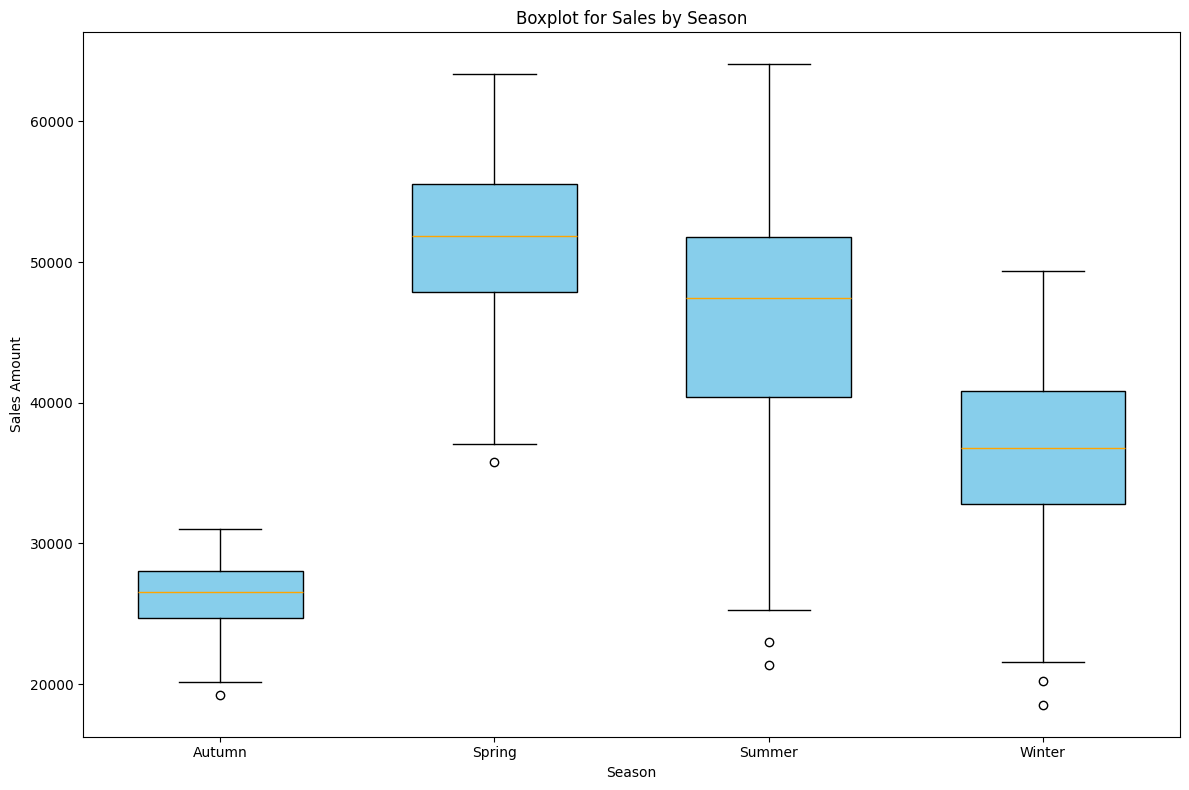

In [36]:
# This line groups the data by the 'Season' column and add up all the dates sales according to the season.
# Then the result is stored in 'season_sales' DataFrame variable
season_sales = data.groupby('Season')[numeric_cols].sum()

# This creates a figure window for the plot with a set size (12' wide, 8' high)
plt.figure(figsize=(12, 8)) 

# The for loop iterates through each season (index) in the season_sales DataFrame
# plt.boxplot() creates a boxplot of the retrieved data.
# .loc[season]  - retrieves the data for that specific season from season_sales
# positions=[i]  - sets the position of the boxplot on the x-axis based on the loop counter i. This ensures each season's boxplot appears at a distinct location
# widths=0.6 - controls the width of the boxplot boxes
# patch_artist=True - allows for further customization of the boxplot appearance.
# boxprops=dict(facecolor='skyblue', color='black') - sets the fill color and border color of the boxplot boxes.
# medianprops=dict(color='orange') - sets the color of the line representing the median value within the boxplot.
for i, season in enumerate(season_sales.index):
    plt.boxplot(season_sales.loc[season], positions=[i], widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='skyblue', color='black'), medianprops=dict(color='orange'))

# Adding title name for the graph
plt.title('Boxplot for Sales by Season')
# Naming the x & y axis
plt.xlabel('Season')
plt.ylabel('Sales Amount')
# This line assigns labels to the x-axis ticks using plt.xticks. 
# It ensures each boxplot has the corresponding season name (from season_sales.index) displayed below it
plt.xticks(range(len(season_sales.index)), season_sales.index)

# Helps in adjusting spaces between boxplots
plt.tight_layout()
# Display the plot
plt.show()

# 2.4. Influence of Recommendation towards Sales

In [53]:
# This line groups the DataFrame data by the column "Recommendation". This means it separates the data into two groups, one for "Recommendation='Yes'" and another for "Recommendation='No'"
# Calculate the sales from each season and obtaing the mean
data.groupby("Recommendation")[["Summer","Spring","Autumn","Winter"]].mean()

,Summer,Spring,Autumn,Winter
Recommendation,,,,
0,1430.149635,298.051095,2840.193431,985.660584
1,1463.639024,302.117073,2854.024390,998.107317


# 2.5. Counting All Unique values from each categorical column 

Count of Unique Values for Each Column:
Style           12
Price            5
Size             5
Season           4
NeckLine        15
SleeveLength     9
Material        21
FabricType      18
Decoration      24
PatternType     13
dtype: int64


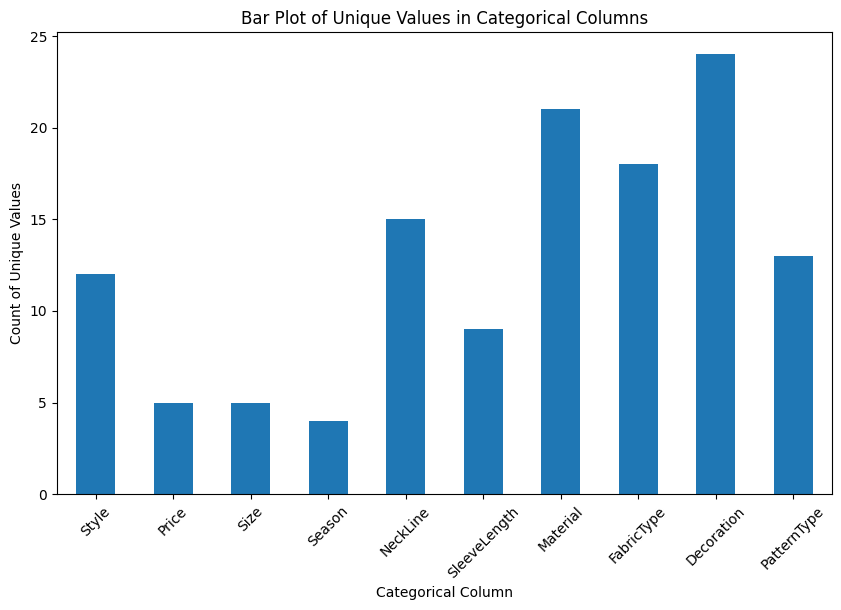

In [40]:
# This line identifies the categorical columns in data DataFrame that has object data type
# Then store the results in categorical_columns variable
categorical_columns = data.select_dtypes(include=['object']).columns

# This line uses the .nunique() method to the list of categorical column names & 
# Count the number of unique values in the DataFrame then stores the result in Series - unique_value_counts 
unique_value_counts = data[categorical_columns].nunique()  # Fix usage of nunique()

# Display the count of unique values for each column
print("Count of Unique Values for Each Column:")
print(unique_value_counts)

# Creating a bar plot for the count of unique values in each categorical column

# This creates a figure window for the plot with a set size (10' wide, 6' high)
plt.figure(figsize=(10, 6))
# This line creates a bar plot using the unique_value_counts Series
# categorical column names becomes the x-axis labels
# number of unique values become the heights of the bars
unique_value_counts.plot(kind='bar')

# Adding title name for the graph
plt.title('Bar Plot of Unique Values in Categorical Columns')
# Naming the x & y axis
plt.xlabel('Categorical Column')
plt.ylabel('Count of Unique Values')
# Rotate the labels in the x-axis by 45 degrees to prevent overlapping
plt.xticks(rotation=45)
# Display the plot
plt.show()


# 2.6. Analysing the effects of Recommendation and Ratings

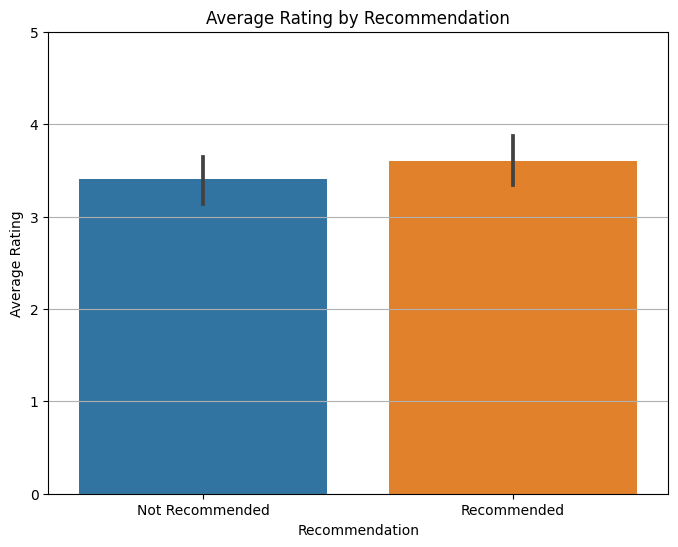

In [48]:
# This creates a figure window for the plot with a set size (8' wide, 6' high)
plt.figure(figsize=(8, 6))

# Using seaborn.barplot function to create a bar chart 
#  x='Recommendation':sets the variable on the x-axis (horizontal) to be recommendation
#  y='Rating': sets the variable on the y-axis (vertical) to be Rating 
#  data=data: using the data DataFrame
sns.barplot(x='Recommendation', y='Rating', data=data)

# Adding title name for the graph
plt.title('Average Rating by Recommendation')
# Naming the x & y axis
plt.xlabel('Recommendation')
plt.ylabel('Average Rating')

# Customising the x axis
#  [0, 1]: specifying the positions of the tick labels on the x-axis to be at positions 0 and 1
#  Then specfying 0 to be Not recommended & 1 to be Recommended
plt.xticks([0, 1], ['Not Recommended', 'Recommended'])

# Setting the limit of the y axis from 0 to 5
plt.ylim(0, 5)
# Adding grid lines to the x axis
plt.grid(axis='y')
# Display the plot
plt.show()


# 2.7. Scatter Plot of Ratings against Sales

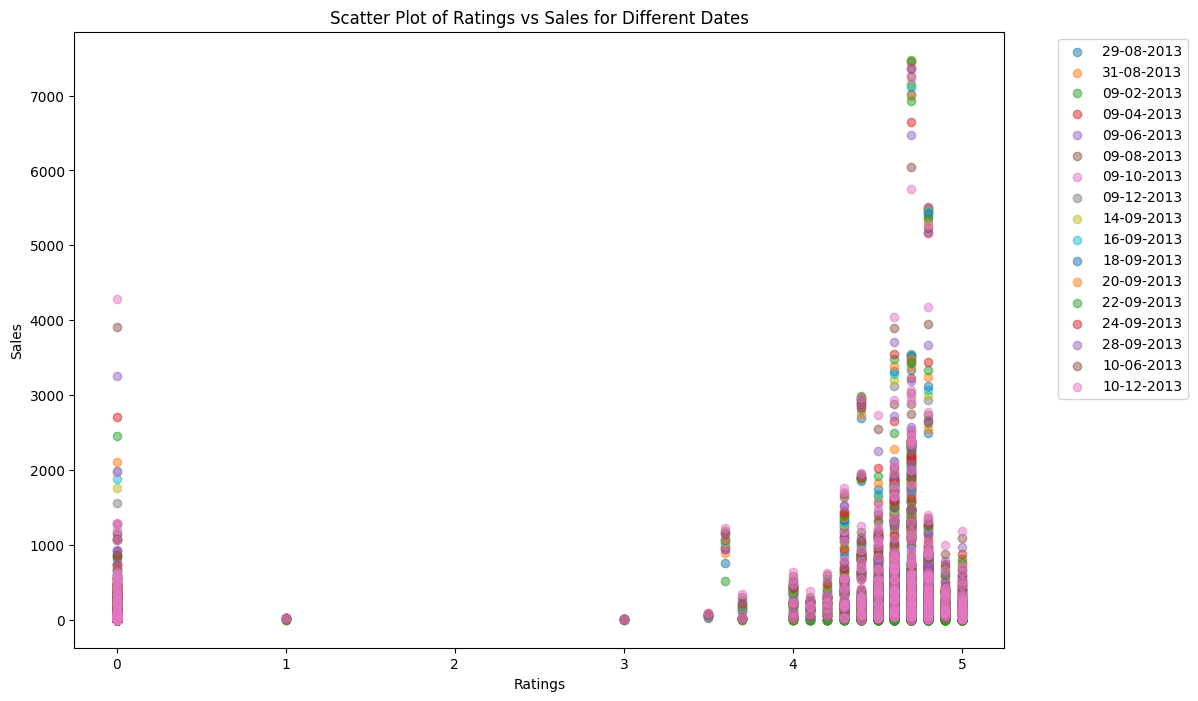

In [41]:
# FInding the correlation of ratings and sales 
# - idea of if there are higher ratings, would the sales be most likely higher?

# This line "Rating" in data DataFrame & assigns it to the ratings variable
ratings = data['Rating']

# This line defines the columns of date 
date_columns = ['29-08-2013', '31-08-2013', '09-02-2013', '09-04-2013', '09-06-2013', '09-08-2013', '09-10-2013', '09-12-2013', '14-09-2013', '16-09-2013', '18-09-2013', '20-09-2013', '22-09-2013', '24-09-2013', '28-09-2013', '10-06-2013', '10-12-2013']

# This part of the code snippet create a scatter plot for each date column
# This creates a new figure window for the plot with a customized size (12' wide, 8' high)
plt.figure(figsize=(12, 8))
for date_column in date_columns:
    # This line retrieves the sales data for the current date column from data DataFrame 
    # This becomes the y-axis data 
    #  alpha=0.5 - sets the opacity of the data points to 0.5 
    # label=date_column - ssigns a label to each scatter plot series using the current date column name (legend)
    plt.scatter(ratings, data[date_column], alpha=0.5, label=date_column)

# Adding title name for the graph 
plt.title('Scatter Plot of Ratings vs Sales for Different Dates')
# Naming the x & y axis
plt.xlabel('Ratings')
plt.ylabel('Sales')

# This line creates a legend to differentiate the scatter plots for each date
# This legend is situated at the (upper left corner to avoid overlapping with the data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# This line displays the created scatter plot
plt.show()

# 2.8. Analysing recommendation of Sizes 

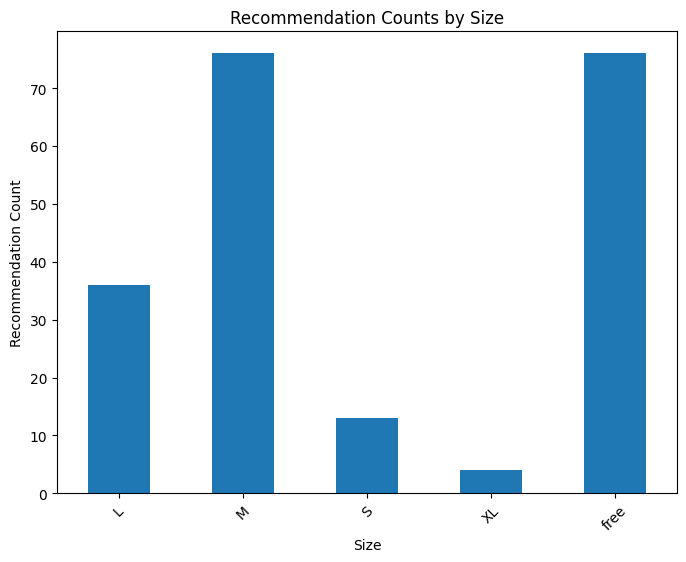

In [57]:
# This line calculates the sum of the values in the "Recommendation" column for each size
#   .groupby("Size"): Using groupby function for Size column from data DataFrame
#   ["Recommendation"]: selecting specific column "Recommendation" from the grouped data
recommendation_sum = data.groupby("Size")["Recommendation"].sum()

# Creating the bar plot
# This line creates a bar chart to visualize the data in the recommendation_sum
# This creates a new figure window for the plot with a customized size (8' wide, 6' high)
recommendation_sum.plot(kind='bar', figsize=(8, 6))

# Adding title name for the graph
plt.title('Recommendation Counts by Size')
# Naming the x & y axis
plt.xlabel('Size')
plt.ylabel('Recommendation Count')

# Rotate the labels in the x-axis by 45 degrees to prevent overlapping
plt.xticks(rotation=45)
# Display the plot
plt.show()


# 2.9. Analysis between Rating, Recommendation and Size

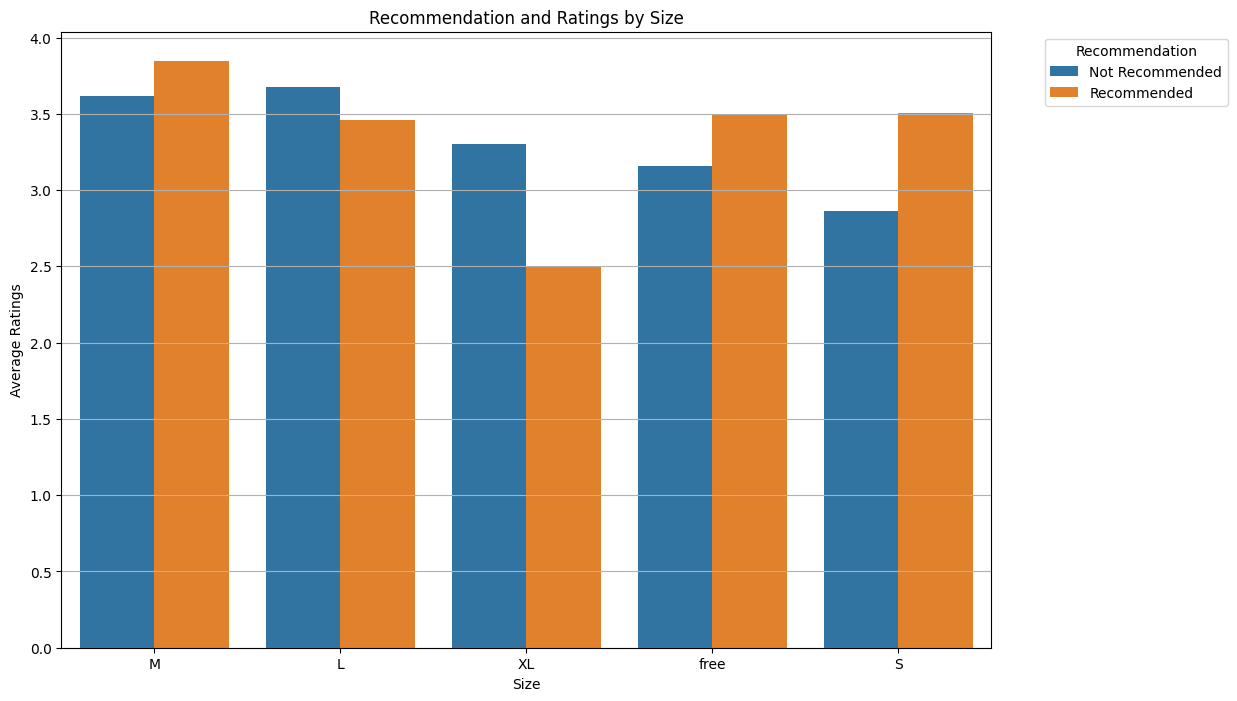

In [64]:
# Creating a barplot for the analysis of Recommendation, Rating and Size

# This creates a new figure window for the plot with a customized size (12' wide, 8' high)
plt.figure(figsize=(12, 8))

# Using the seaborn.barplot function to create a bar chart that visualizes the relationship between size, rating, and recommendation 
#  x='Size': specifies the variable on the x axis to be size column
#  y='Rating': specifies the variable on the y axis to be Ratings column
#  hue='Recommendation': This will create separate bars for "Recommended" and "Not Recommended" sizes  based on colur-coded bars
#  data=data: using the data DataFrame
#  errorbar=None : setting to not display confidence intervals around the means in the chart
sns.barplot(x='Size', y='Rating', hue='Recommendation', data=data, errorbar=None)

# Adding title name for the graph
plt.title('Recommendation and Ratings by Size')
# Naming the x & y axis
plt.xlabel('Size')
plt.ylabel('Average Ratings')

# Move the legend to the upper right outside the plot area
plt.legend(title='Recommendation', labels=['Not Recommended', 'Recommended'], bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding grid lines to the x axis
plt.grid(axis='y')
# Displaying the plot
plt.show()

# 2.10. Contingency / cross tabulation table between Style Price & Size columns

In [42]:
# Creating Cross Tabulation Table / Contingency
# sets the index of the table to the 'Style' column from data DataFrame
# sets the columns of the table to the 'Price' and 'Size' columns from data DataFrame
contingency_table = pd.crosstab(index=data['Style'], columns=[data['Price'], data['Size']])
# Both line prints outs the contingency table
print("Contingency Table:")
print(contingency_table)


Contingency Table:
Price    Average                High                ... Low      Medium        \
Size           L   M  S XL free    L  M  S XL free  ...  XL free      L  M  S   
Style                                               ...                         
Brief          2   5  0  1    4    0  0  0  0    0  ...   1    1      0  0  0   
Casual        25  44  8  7   26    2  1  1  1    1  ...   1   49      3  5  2   
Flare          0   0  0  0    2    0  0  0  0    0  ...   0    0      0  0  0   
Novelty        1   0  1  0    3    0  0  0  0    0  ...   0    0      0  1  0   
OL             0   0  0  0    0    0  0  0  0    0  ...   0    0      0  1  0   
bohemian       2   2  1  0    4    0  0  0  0    0  ...   1    8      0  0  0   
cute           8   9  0  1    3    0  3  0  0    0  ...   1    7      0  0  1   
fashion        0   0  0  0    1    0  0  0  0    0  ...   0    0      0  0  0   
party          1  12  0  0    5    1  8  0  0    0  ...   0    0      0  2  2   
sexy     

# 3. Data Visualisation

# 3.1 Looking at Frequency Distribution of Categorical Variables

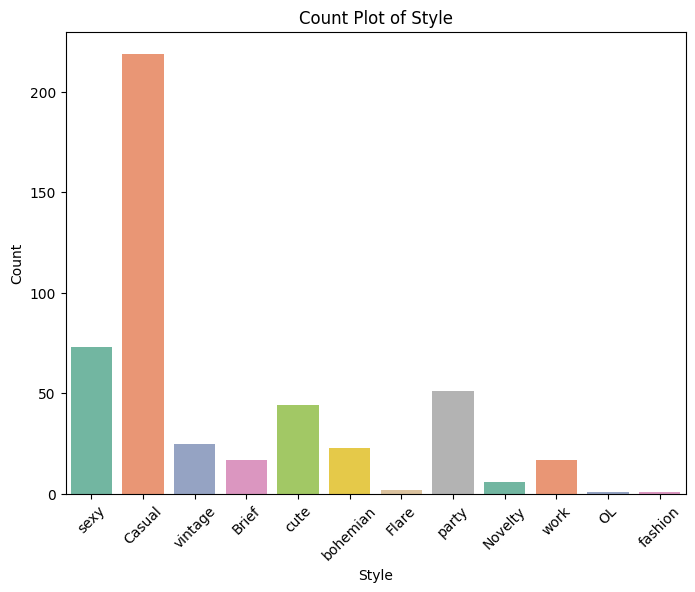

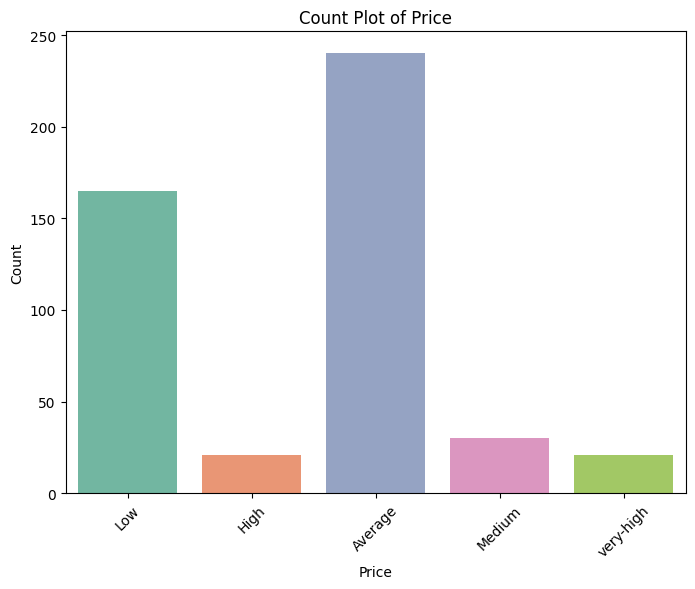

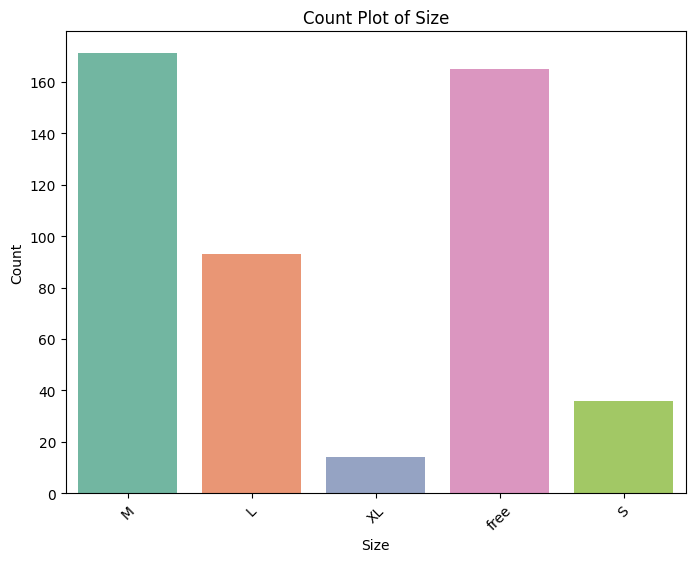

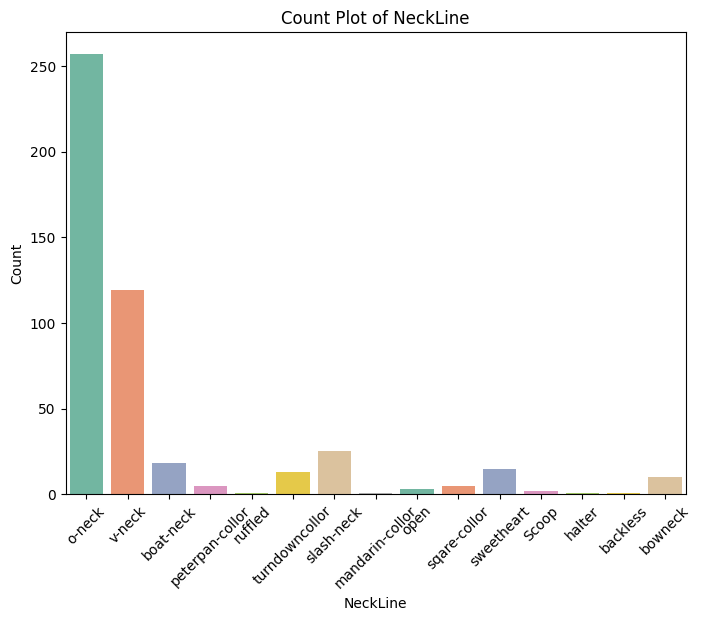

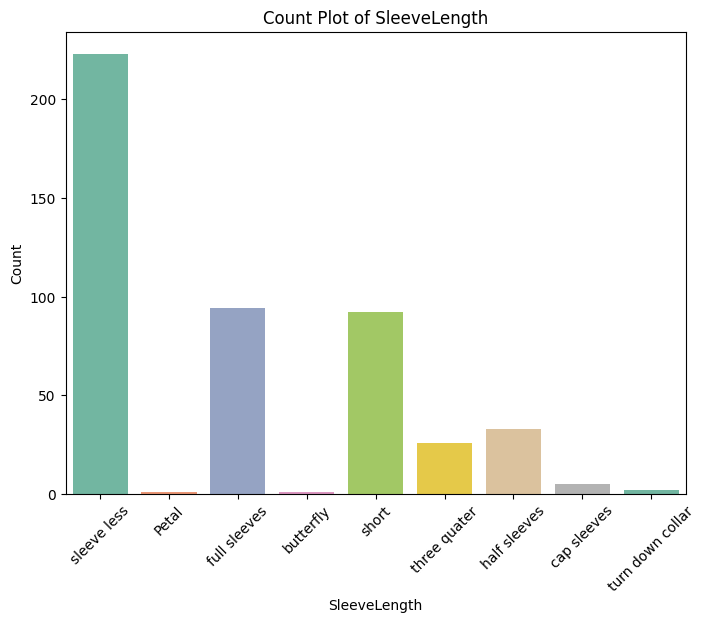

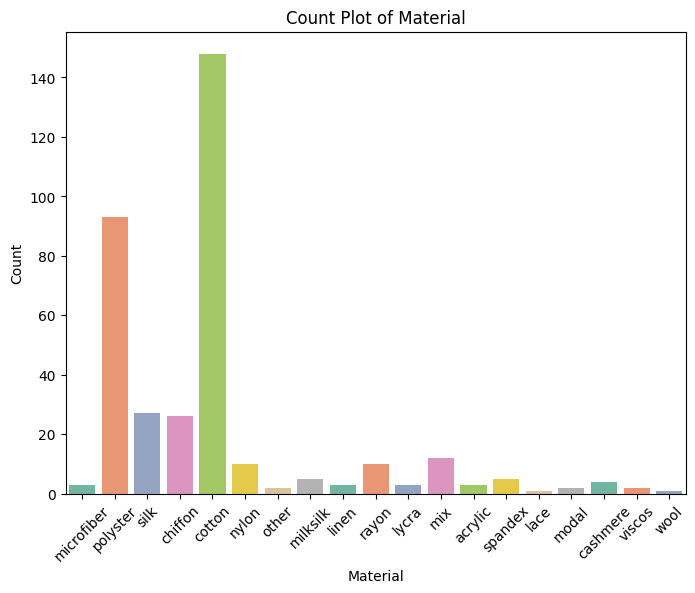

In [65]:
# This line defines a list named categorical_columns selected for data visualisation
categorical_columns = ['Style', 'Price', 'Size', 'NeckLine', 'SleeveLength', 'Material'] 

# Creating bar plots for each categorical variable
# This line starts a loop that assigns each column name from the categorical_columns list to the variable col one by one in each iteration.
for col in categorical_columns:
    # Creating a count plot for the current categorical variable
    # This creates a new figure window for the plot with a customized size (8' wide, 6' high)
    plt.figure(figsize=(8, 6))
# This line is the key part for creating the visualization
    # - specifying the dataset used for the plot = 'data'
    # - This argument tells the function to use the current column name stored in col as the variable on the x-axis of the plot
    # - setting the colour palette with Seaborn's colour scheme
    sns.countplot(data=data, x=col, palette='Set2')

    # Adding title name for the graph 
    plt.title(f'Count Plot of {col}')
    # Naming the x & y axis
    plt.xlabel(col)
    plt.ylabel('Count')  
    # rotates the labels in x axis by 45 degrees to prevent overlapping
    plt.xticks(rotation=45)  
    # This line displays the created count plot
    plt.show()

# 3.2 The trend of sales by each date

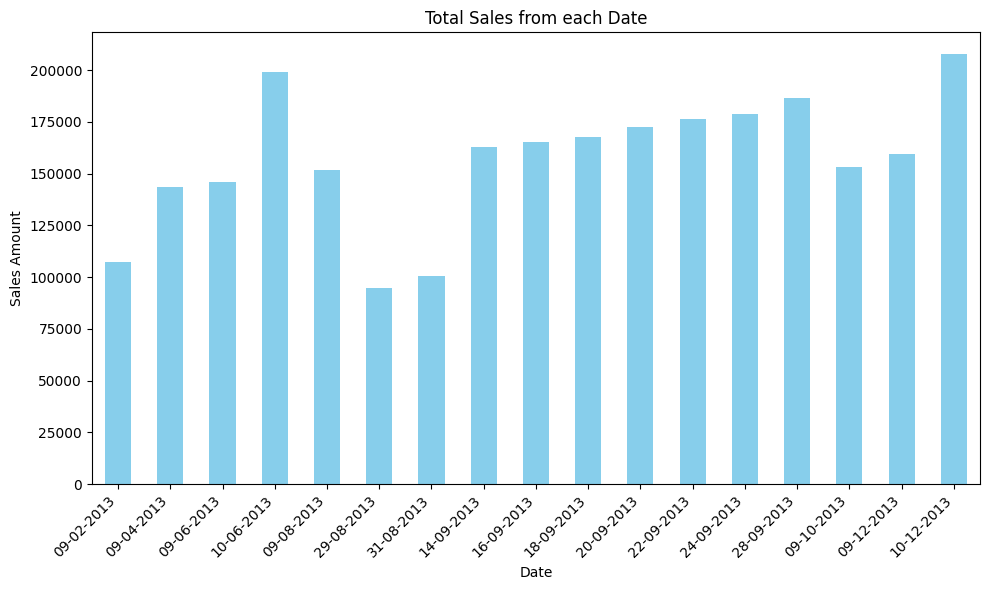

In [42]:
# This line calculate sum for each numeric column from data DataFrame and store it in a new dataframe called as 'column_sums_dates'
column_sums_dates = data[['09-02-2013', '09-04-2013', '09-06-2013', '10-06-2013',  '09-08-2013', '29-08-2013', '31-08-2013', '14-09-2013', '16-09-2013', '18-09-2013', '20-09-2013', '22-09-2013', '24-09-2013', '28-09-2013', '09-10-2013', '09-12-2013',  '10-12-2013']].sum()

# This part of the code snippet create bar plot for total sales from each date
#  This line creates a new figure window for the plot (10'width, 6'height in inches)
plt.figure(figsize=(10, 6)) 

# This line creates the bar plot using the plot method of the column_sums_dates Series 
# kind='bar' - specifies the type of plot as a bar chart.
# 'color='skyblue' - sets the color of the bars to sky blue
column_sums_dates.plot(kind='bar', color='skyblue')

# Adding title name for the graph 
plt.title('Total Sales from each Date')
# Naming the x & y axis
plt.xlabel('Date')
plt.ylabel('Sales Amount')
# This line adjusts the x-axis tick labels (dates)
# rotation=45: rotates the labels by 45 degrees to prevent overlapping.
# ha='right': right-aligns the rotated labels within the x-axis tick positions.
plt.xticks(rotation=45, ha='right') 

# This adjusts the spacing between the plot elements (bars, labels, title) to avoid overlapping or excessive white space
plt.tight_layout()
# This line displays the created bar chart
plt.show()

# 3.3. Sales of each Season 

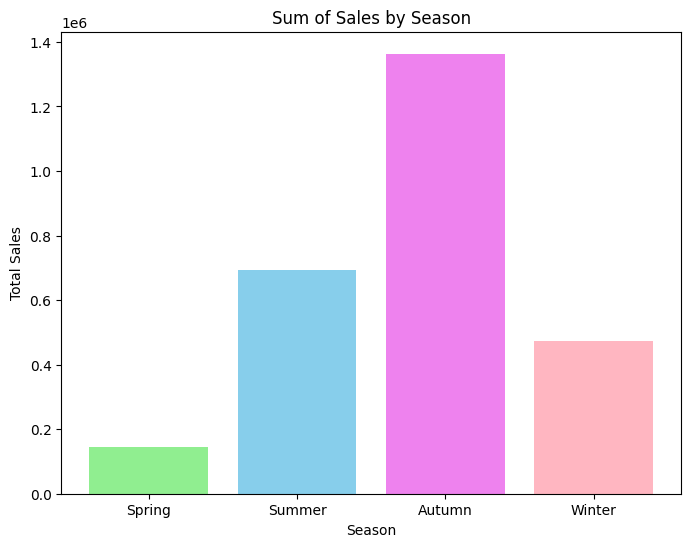

In [34]:
# This line calculate sum for each season from data DataFrame and store it in a new dataframe called as 'column_sums_seasons'
column_sums_seasons = data[['Spring', 'Summer', 'Autumn', 'Winter']].sum()

# This line essentially extracts the row labels (representing the seasons) and assigns them to the new variable seasons
seasons = column_sums_seasons.index
# this line extracts the numerical data from the DataFrame column_sums_seasons and assigns it to the new variable sales
sales = column_sums_seasons.values

# Defining colours for each season
colors = ['lightgreen', 'skyblue', 'violet', 'lightpink']

#  This line creates a new figure window for the plot (10'width, 6'height in inches)
plt.figure(figsize=(8, 6))
# The x-axis: (seasons) shows the season categories.
# The y-axis:  (season_totals) shows the total sales for each season.
# The bar colours are set to skyblue
plt.bar(seasons, sales, color=colors)

# Adding title name for the graph 
plt.title('Sum of Sales by Season')
# Naming the x & y axis
plt.xlabel('Season')
plt.ylabel('Total Sales')

# Displaying the plot
plt.show()

# 3.4. Influence of Style from Sales of each Season

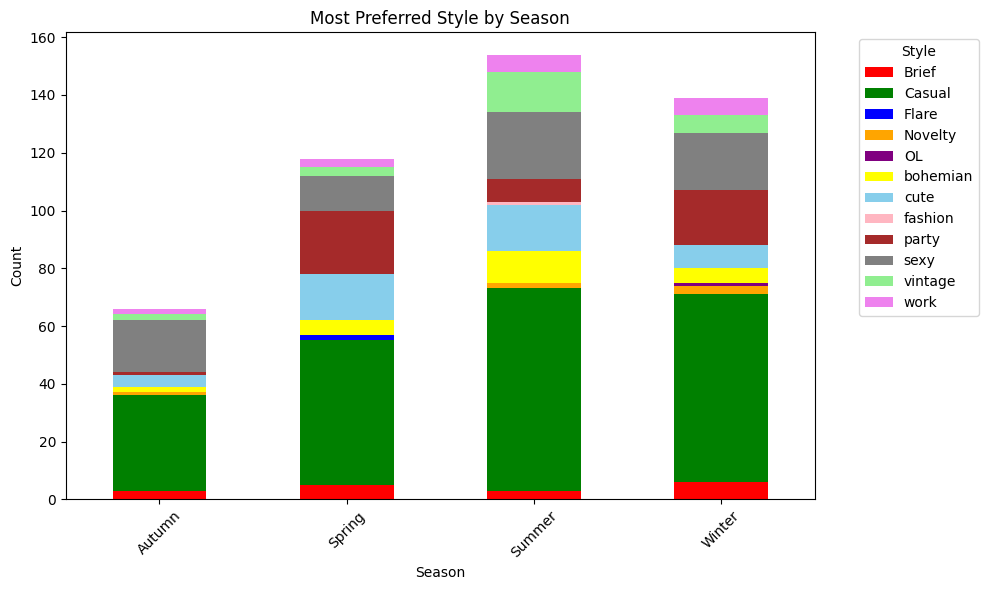

In [35]:
# Group by season and style, count occurrences, and unstack to pivot the style counts
# data.groupby(['Season', 'Style']): his creates groups where each entry has a specific season and style combination. 
# .size(): counts how many times each unique combination of season and style appears in the data.
# .unstack(fill_value=0): This method takes the result from the counting how many times that style appeared in that season
season_style_counts = data.groupby(['Season', 'Style']).size().unstack(fill_value=0)

#  This line creates a new figure window for the plot (10'width, 6'height)
fig, ax = plt.subplots(figsize=(10, 6))
# This creates a figure (fig) and an axes object (ax) for the plot
#  season_style_counts as a bar chart
# kind='bar' specifies a bar chart, and stacked=True stacks the bars for each season on top of each other.
# ax=ax : specifies the axes (ax) where the plot should be drawn
# Defining colours for each style category
season_style_counts.plot(kind='bar', stacked=True, ax=ax, color=['red', 'green', 'blue', 'orange', 'purple', 'yellow', 'skyblue', 'lightpink', 'brown', 'grey', 'lightgreen', 'violet', 'pink'])

# Naming the x & y axis
ax.set_xlabel('Season')
ax.set_ylabel('Count')
# Adding title name for the graph 
ax.set_title('Most Preferred Style by Season')

# rotates the labels in x axis by 45 degrees to prevent overlapping
plt.xticks(rotation=45)  
# This line creates a legend to differentiate the bar cahrt for each season
# This legend is situated at the (upper left corner to avoid overlapping with the bar chart
plt.legend(title='Style', bbox_to_anchor=(1.05, 1), loc='upper left')
# This adjusts the spacing between the plot elements (bars, labels, title) to avoid overlapping or excessive white space
plt.tight_layout()
# This line displays the created bar chart
plt.show()


# 3.5. Influence of Material from Sales of each Season

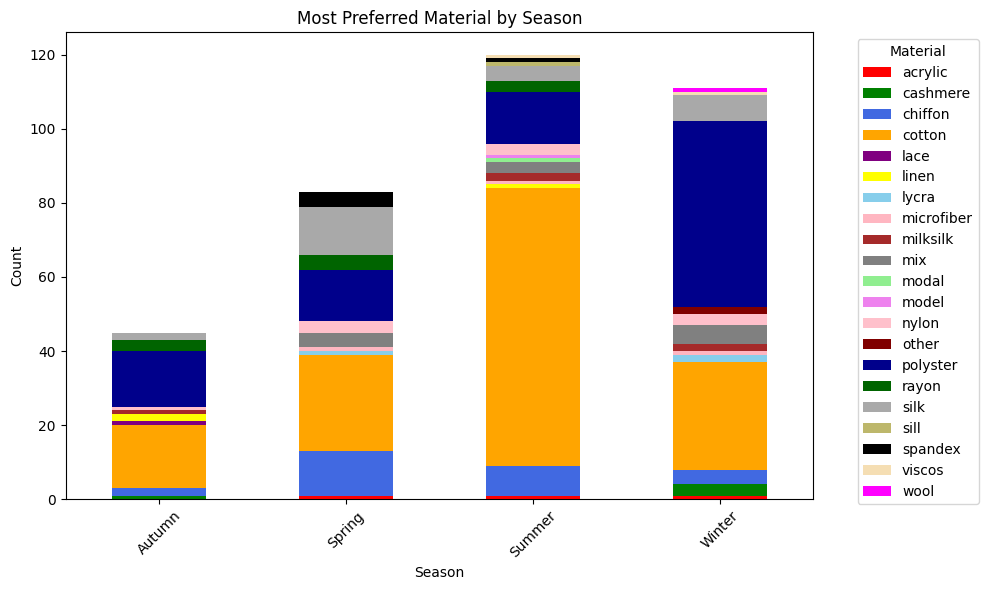

In [40]:
# Group by season and material, count occurrences, and unstack to pivot the material counts
# data.groupby(['Season', 'Material']): his creates groups where each entry has a specific season and material combination. 
# .size(): counts how many times each unique combination of season and material appears in the data.
# .unstack(fill_value=0): This method takes the result from the counting how many times that material appeared in that season
season_material_counts = data.groupby(['Season', 'Material']).size().unstack(fill_value=0)

#  This line creates a new figure window for the plot (10'width, 6'height)
fig, ax = plt.subplots(figsize=(10, 6))
# This creates a figure (fig) and an axes object (ax) for the plot
#  season_material_counts as a bar chart
# kind='bar' specifies a bar chart, and stacked=True stacks the bars for each season on top of each other.
# ax=ax : specifies the axes (ax) where the plot should be drawn
# Defining colours for each style category
season_material_counts.plot(kind='bar', stacked=True, ax=ax, color=['red', 'green', 'royalblue', 'orange', 'purple', 'yellow', 'skyblue', 'lightpink', 'brown', 'grey', 'lightgreen', 'violet', 'pink', 'maroon', 'darkblue', 'darkgreen', 'darkgrey', 'darkkhaki', 'black', 'wheat', 'magenta'])

# Naming the x & y axis
ax.set_xlabel('Season')
ax.set_ylabel('Count')
# Adding title name for the graph 
ax.set_title('Most Preferred Material by Season')
# rotates the labels in x axis by 45 degrees to prevent overlapping
plt.xticks(rotation=45)  

# This legend is situated at the (upper left corner to avoid overlapping with the bar chart
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
# This adjusts the spacing between the plot elements (bars, labels, title) to avoid overlapping or excessive white space
plt.tight_layout()
# This line displays the created bar chart
plt.show()